# 07 — Monte Carlo & Volatility Decay

**Goal:** understand *when* leverage helps and *when* it destroys wealth, by simulating thousands of random markets with known drift and volatility.

*(This notebook uses a small, fast simulation grid so it runs in seconds. The full 10,000-path grid lives in `run_all.py`.)*

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import monte_carlo as mc, plots as pl, config

## First, the arithmetic — why a flat, choppy market loses money

Consider one up day of +10% then one down day of −10%:

In [3]:
mc.vol_decay_table()

,leverage,day1_+10%_move,day2_-10%_move,after_day1,after_day2,two_day_return
0,1x,0.1000,-0.1000,1.1000,0.9900,-0.0100
1,2x,0.2000,-0.2000,1.2000,0.9600,-0.0400
2,3x,0.3000,-0.3000,1.3000,0.9100,-0.0900


A 1x investor ends at 0.99 (−1%). The 2x investor ends at −4%, the 3x at −9%. The market went nowhere, yet leverage **lost money** — and the loss grows with the *square* of leverage. That is **volatility decay**. The closed-form penalty is `0.5 × L² × volatility²` per year:

In [4]:
for L in [1,2,3]:
    print(f'{L}x at 20% vol: variance drag ≈ {mc.variance_drag(L,0.20):.2%} per year')

1x at 20% vol: variance drag ≈ 2.00% per year
2x at 20% vol: variance drag ≈ 8.00% per year
3x at 20% vol: variance drag ≈ 18.00% per year


## The teaching picture: same leverage, two different paths

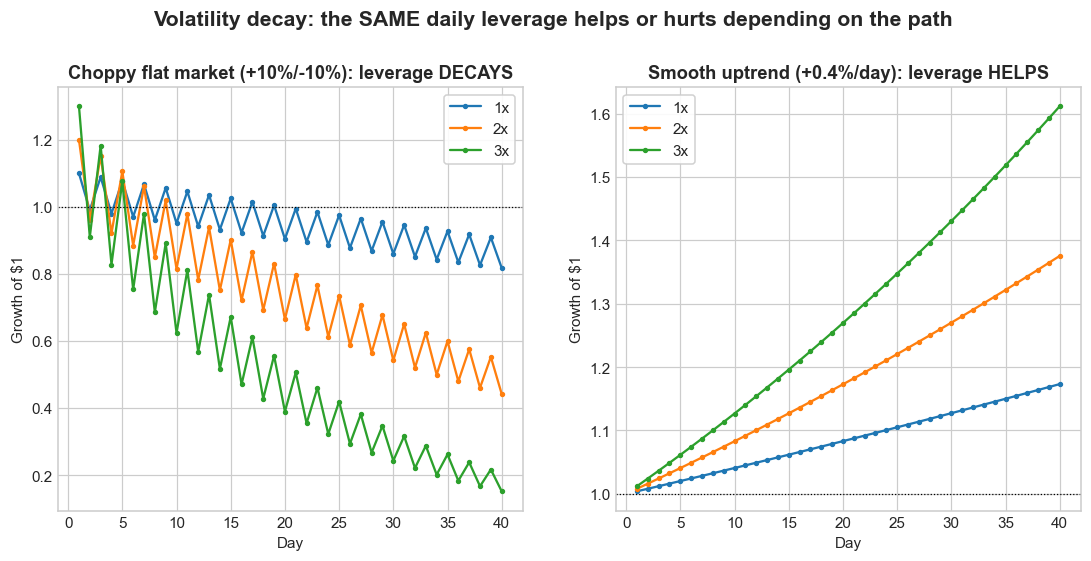

In [5]:
fig = pl.plot_vol_decay_example('volatility_decay_example.png'); plt.show()

Left: a choppy flat market — leverage decays. Right: a smooth uptrend — leverage helps. **The path matters as much as the destination.**

## Monte Carlo grid: optimal leverage by drift & volatility

We simulate many 10-year paths for a range of drifts and volatilities, apply each leverage to the *same* random draws, and find the leverage that maximises median terminal wealth.

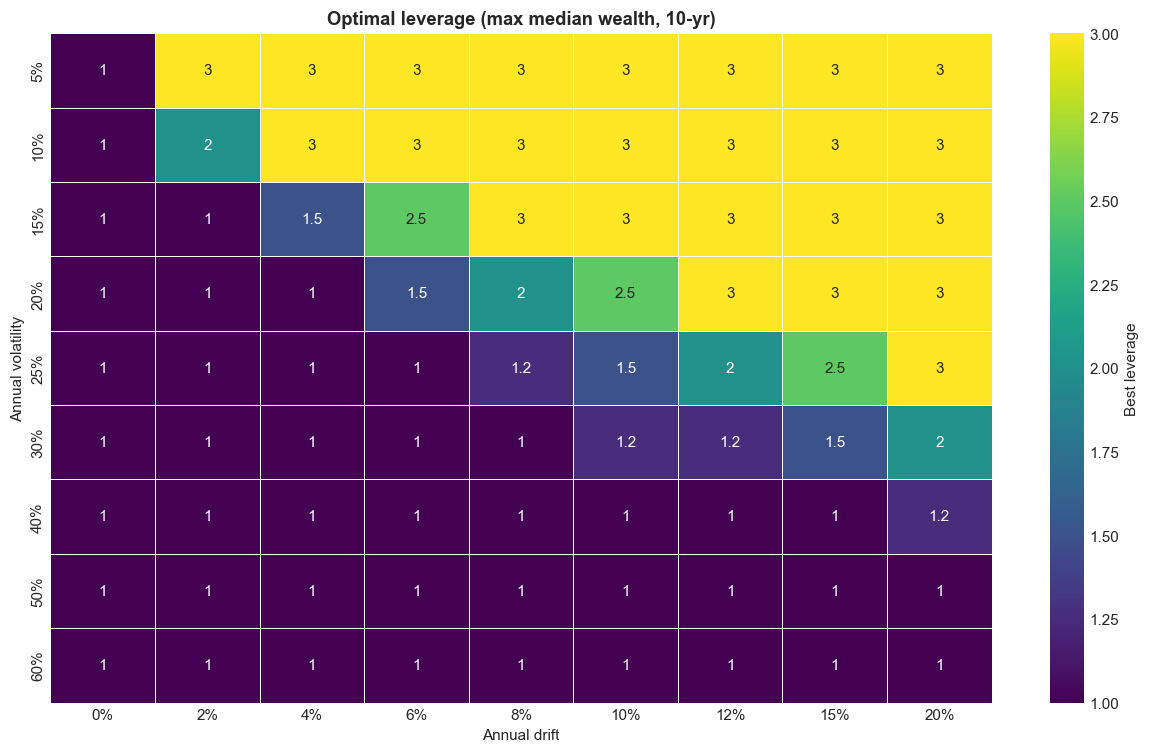

In [6]:
# small/fast grid for the notebook: 10-year horizon only, fewer paths
# (the full 5-horizon, 10,000-path grid lives in run_all.py)
grid = mc.run_grid(horizons_years=[10], n_paths=1500, verbose=False)
opt = mc.optimal_leverage_grid(grid, 10, objective='median_terminal')
opt.index = [f'{v:.0%}' for v in opt.index]
opt.columns = [f'{d:.0%}' for d in opt.columns]
fig = pl.plot_heatmap(opt, 'Optimal leverage (max median wealth, 10-yr)',
    '07_mc_optimal_leverage.png', fmt='.2g', cmap='viridis',
    xlabel='Annual drift', ylabel='Annual volatility', cbar_label='Best leverage')
plt.show()

**The frontier is diagonal.** High leverage (3x) is optimal only in the **top-right**: low volatility *and* strong drift. As volatility rises (moving down), the optimal leverage collapses to **1x** — at 40%+ volatility you should not leverage at *any* realistic drift.

**Now connect it to our strategy.** We add leverage when the market is *below* its moving average — and below-trend periods are exactly the **high-volatility, low-drift** regimes (bottom-left of this map), where the optimal leverage is 1x. The strategy leverages precisely where the math says it should not. That is why it failed on real data.

## Probability that 2x and 3x beat 1x

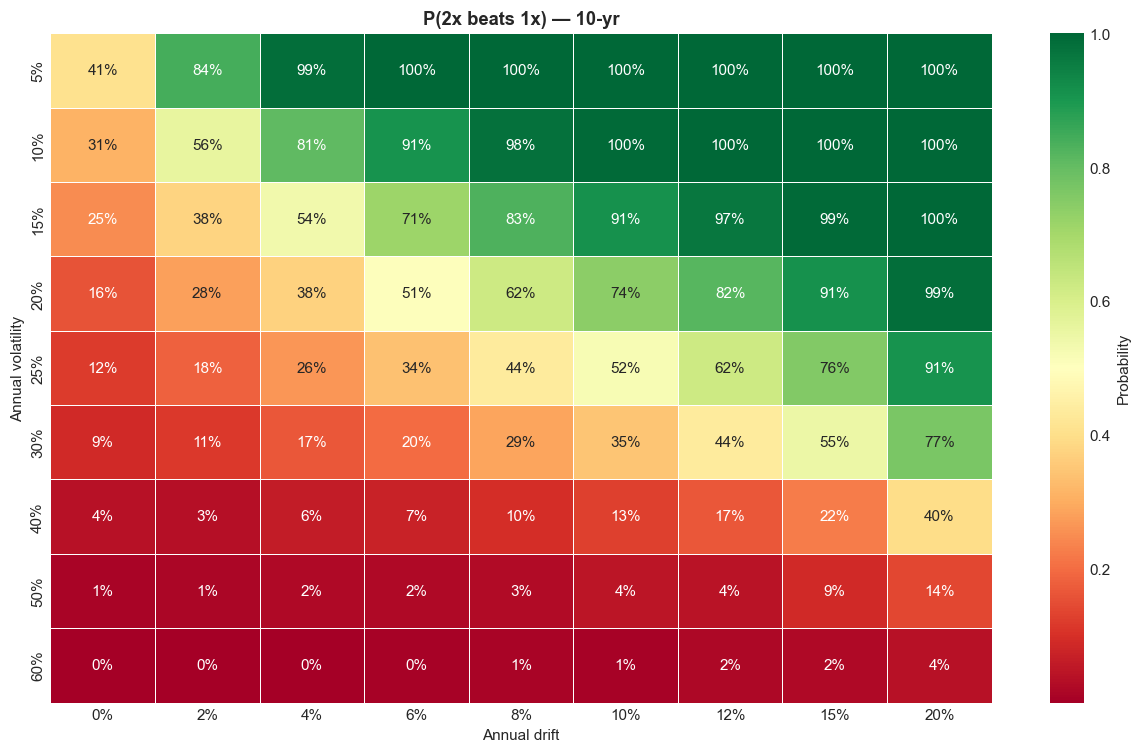

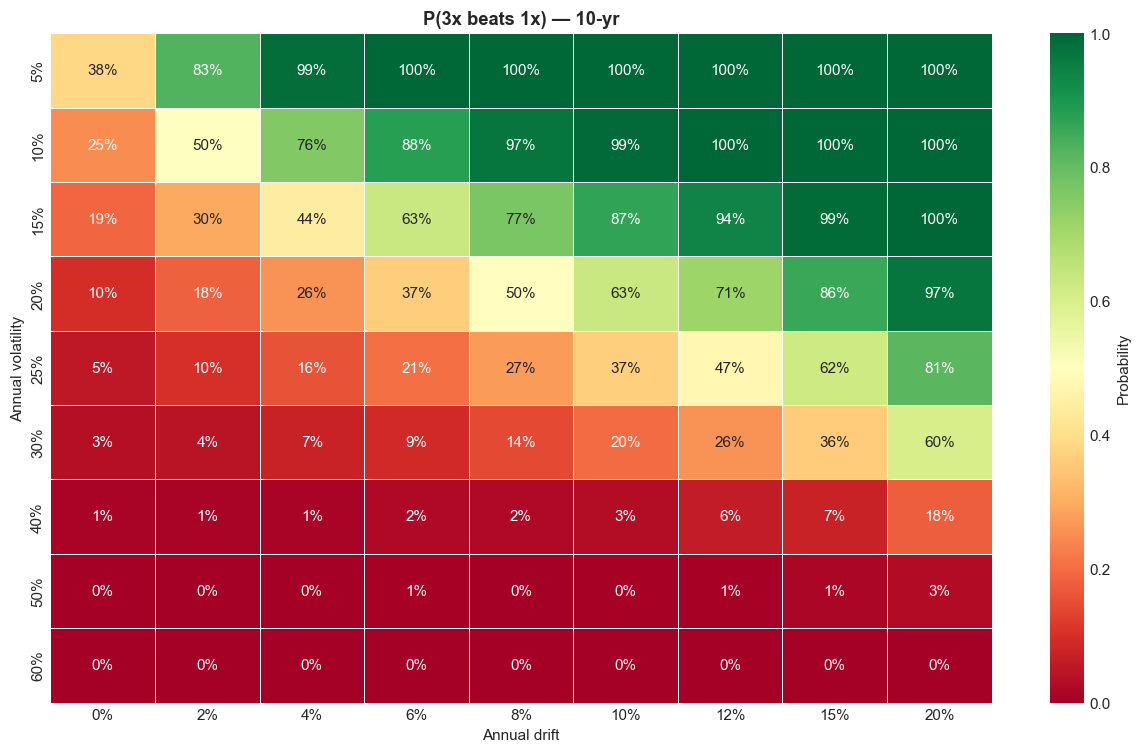

In [7]:
for L in [2.0, 3.0]:
    m = mc.prob_beat_1x_grid(grid, 10, L)
    m.index = [f'{v:.0%}' for v in m.index]; m.columns=[f'{d:.0%}' for d in m.columns]
    fig = pl.plot_heatmap(m, f'P({L:g}x beats 1x) — 10-yr', f'07_mc_prob_{int(L)}x_beats_1x.png',
        fmt='.0%', cmap='RdYlGn', center=0.5, xlabel='Annual drift',
        ylabel='Annual volatility', cbar_label='Probability'); plt.show()

➡️ **Next:** notebook 08 pulls every headline number together and states the verdict.